# Agent Graph 구조 시각화

각 에이전트의 내부 흐름을 방향 그래프로 표현합니다.

In [4]:
!uv pip install matplotlib/


Using Python 3.11.14 environment at: /Users/bae/Workspace/langchain-v1/.venv
error: Distribution not found at: file:///Users/bae/Workspace/rag-agent/docs/matplotlib


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 공통 스타일 ──────────────────────────────────────────
COLORS = {
    "io":      "#4A90D9",   # 입출력 (파랑)
    "llm":     "#E8734A",   # LLM 호출 (주황)
    "rag":     "#6BBF59",   # RAG/벡터스토어 (초록)
    "tool":    "#9B59B6",   # Tool / 서브에이전트 (보라)
    "logic":   "#F1C40F",   # 라우팅/분기 (노랑)
    "default": "#BDC3C7",   # 기본 (회색)
}
FONT = "Malgun Gothic" if __import__('sys').platform == 'win32' else "AppleGothic"
plt.rcParams['font.family'] = FONT
plt.rcParams['axes.unicode_minus'] = False


def draw_graph(G, pos, node_colors, title, ax, node_size=3000, font_size=8):
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=font_size, font_color='white',
                            font_weight='bold', ax=ax)
    nx.draw_networkx_edges(
        G, pos,
        arrows=True, arrowsize=18, arrowstyle='-|>',
        edge_color='#555555', width=1.5,
        connectionstyle='arc3,rad=0.05',
        ax=ax,
        min_source_margin=25, min_target_margin=25,
    )
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=14)
    ax.axis('off')

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. SearchAgent (Supervisor)

/Users/bae/Workspace/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


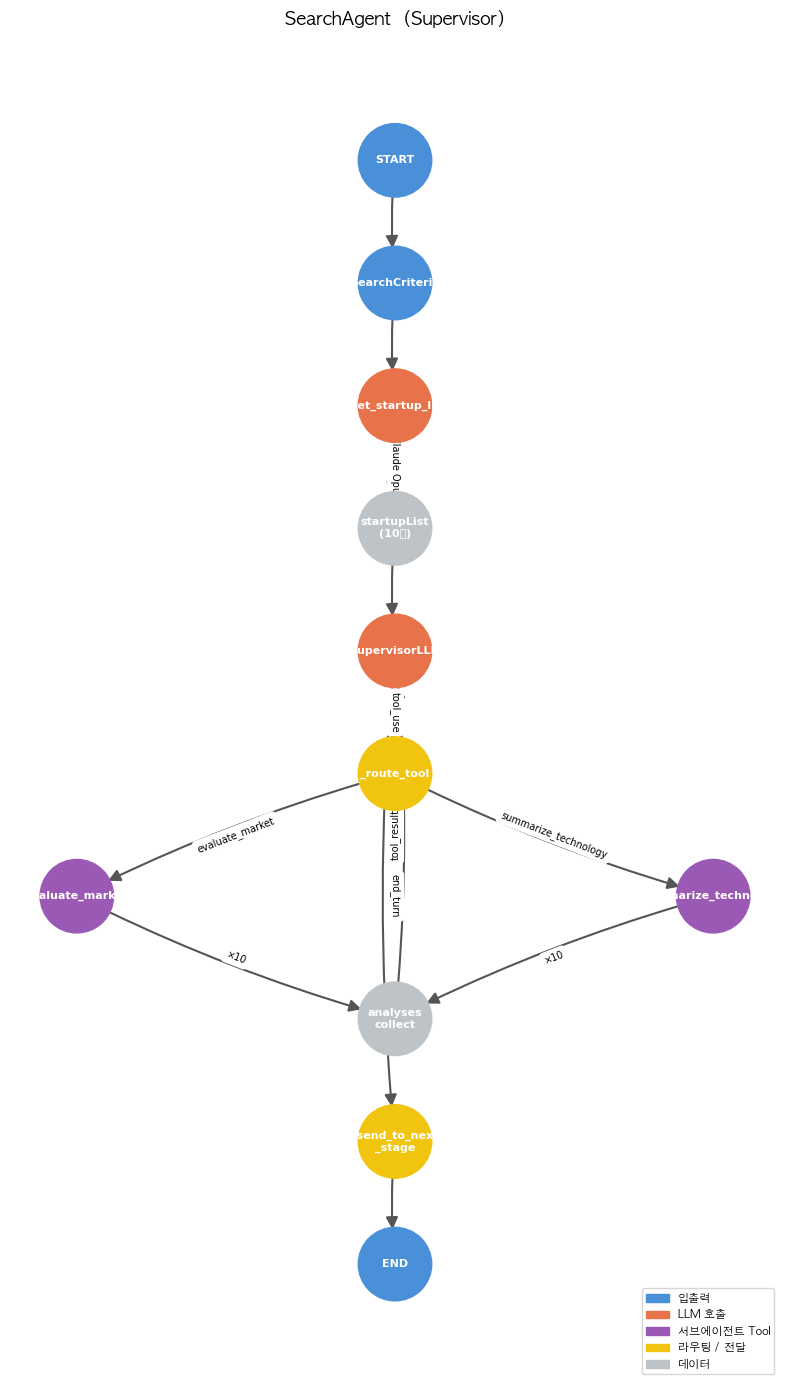

In [2]:
# ── 노드 정의 ──────────────────────────────────────────
search_nodes = [
    ("START",             "io"),
    ("SearchCriteria",    "io"),
    ("_get_startup_list", "llm"),
    ("startupList\n(10개)",  "default"),
    ("SupervisorLLM",     "llm"),
    ("_route_tool",       "logic"),
    ("evaluate_market",   "tool"),
    ("summarize_technology", "tool"),
    ("analyses\ncollect", "default"),
    ("_send_to_next\n_stage", "logic"),
    ("END",               "io"),
]

# ── 엣지 정의 ──────────────────────────────────────────
search_edges = [
    ("START",             "SearchCriteria",       ""),
    ("SearchCriteria",    "_get_startup_list",    ""),
    ("_get_startup_list", "startupList\n(10개)",  "Claude Opus"),
    ("startupList\n(10개)",  "SupervisorLLM",     ""),
    ("SupervisorLLM",     "_route_tool",          "tool_use"),
    ("_route_tool",       "evaluate_market",      "evaluate_market"),
    ("_route_tool",       "summarize_technology", "summarize_technology"),
    ("evaluate_market",   "analyses\ncollect",    "×10"),
    ("summarize_technology", "analyses\ncollect", "×10"),
    ("analyses\ncollect", "SupervisorLLM",        "tool_result"),
    ("SupervisorLLM",     "_send_to_next\n_stage", "end_turn"),
    ("_send_to_next\n_stage", "END",              ""),
]

G_search = nx.DiGraph()
G_search.add_nodes_from([n for n, _ in search_nodes])
G_search.add_edges_from([(s, t, {'label': l}) for s, t, l in search_edges])

node_color_map = dict(search_nodes)
search_node_colors = [COLORS[node_color_map[n]] for n in G_search.nodes]

# ── 레이아웃 (수동 배치) ──────────────────────────────────
search_pos = {
    "START":                  (0,  10),
    "SearchCriteria":         (0,   8.5),
    "_get_startup_list":      (0,   7),
    "startupList\n(10개)": (0,   5.5),
    "SupervisorLLM":          (0,   4),
    "_route_tool":            (0,   2.5),
    "evaluate_market":        (-2,  1),
    "summarize_technology":   ( 2,  1),
    "analyses\ncollect":      (0,  -0.5),
    "_send_to_next\n_stage":  (0,  -2),
    "END":                    (0,  -3.5),
}

fig, ax = plt.subplots(figsize=(8, 14))
draw_graph(G_search, search_pos, search_node_colors,
           "SearchAgent  (Supervisor)", ax, node_size=2800)

legend_handles = [
    mpatches.Patch(color=COLORS['io'],     label='입출력'),
    mpatches.Patch(color=COLORS['llm'],    label='LLM 호출'),
    mpatches.Patch(color=COLORS['tool'],   label='서브에이전트 Tool'),
    mpatches.Patch(color=COLORS['logic'],  label='라우팅 / 전달'),
    mpatches.Patch(color=COLORS['default'],label='데이터'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 2. MarketEvalAgent (RAG 파이프라인)

/Users/bae/Workspace/.venv/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/Users/bae/Workspace/.venv/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/Users/bae/Workspace/.venv/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/Users/bae/Workspace/.venv/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:254: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/Users/bae/Workspace/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53244 (\N{HANGUL SYLLABLE KWEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

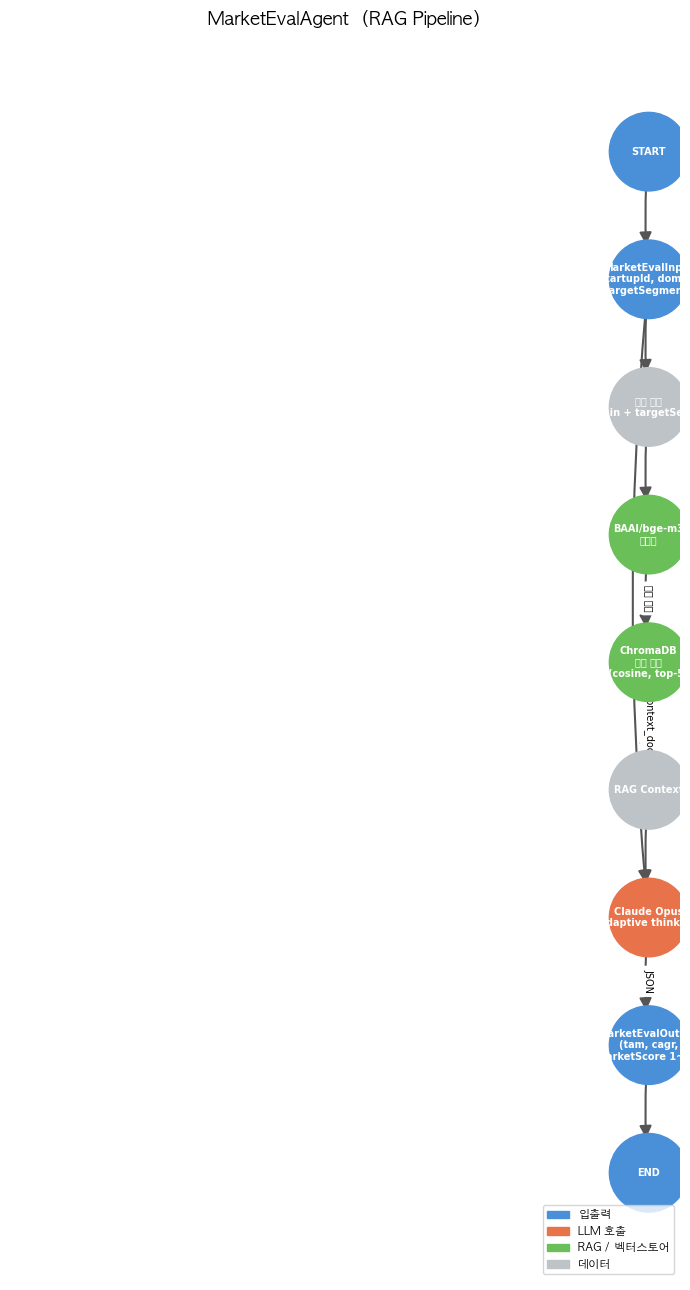

In [3]:
market_nodes = [
    ("START",                 "io"),
    ("MarketEvalInput\n(startupId, domain,\ntargetSegment)", "io"),
    ("쿼리 생성\n(domain + targetSegment)", "default"),
    ("BAAI/bge-m3\n임베딩",   "rag"),
    ("ChromaDB\n벡터 검색\n(cosine, top-5)", "rag"),
    ("RAG Context",           "default"),
    ("Claude Opus\n(adaptive thinking)", "llm"),
    ("MarketEvalOutput\n(tam, cagr,\nmarketScore 1~10)", "io"),
    ("END",                   "io"),
]

market_edges = [
    ("START",
     "MarketEvalInput\n(startupId, domain,\ntargetSegment)", ""),
    ("MarketEvalInput\n(startupId, domain,\ntargetSegment)",
     "쿼리 생성\n(domain + targetSegment)", ""),
    ("쿼리 생성\n(domain + targetSegment)",
     "BAAI/bge-m3\n임베딩", ""),
    ("BAAI/bge-m3\n임베딩",
     "ChromaDB\n벡터 검색\n(cosine, top-5)", ""),
    ("ChromaDB\n벡터 검색\n(cosine, top-5)",
     "RAG Context", "context_docs"),
    ("RAG Context",
     "Claude Opus\n(adaptive thinking)", ""),
    ("MarketEvalInput\n(startupId, domain,\ntargetSegment)",
     "Claude Opus\n(adaptive thinking)", "기업 정보"),
    ("Claude Opus\n(adaptive thinking)",
     "MarketEvalOutput\n(tam, cagr,\nmarketScore 1~10)", "JSON"),
    ("MarketEvalOutput\n(tam, cagr,\nmarketScore 1~10)",
     "END", ""),
]

G_market = nx.DiGraph()
G_market.add_nodes_from([n for n, _ in market_nodes])
G_market.add_edges_from([(s, t, {'label': l}) for s, t, l in market_edges])

color_map_m = dict(market_nodes)
market_node_colors = [COLORS[color_map_m[n]] for n in G_market.nodes]

market_pos = {
    "START":                  (0, 9),
    "MarketEvalInput\n(startupId, domain,\ntargetSegment)": (0, 7.5),
    "쿼리 생성\n(domain + targetSegment)": (0, 6),
    "BAAI/bge-m3\n임베딩":    (0, 4.5),
    "ChromaDB\n벡터 검색\n(cosine, top-5)": (0, 3),
    "RAG Context":            (0, 1.5),
    "Claude Opus\n(adaptive thinking)": (0, 0),
    "MarketEvalOutput\n(tam, cagr,\nmarketScore 1~10)": (0, -1.5),
    "END":                    (0, -3),
}

fig, ax = plt.subplots(figsize=(7, 13))
draw_graph(G_market, market_pos, market_node_colors,
           "MarketEvalAgent  (RAG Pipeline)", ax, node_size=3200, font_size=7)

legend_handles = [
    mpatches.Patch(color=COLORS['io'],     label='입출력'),
    mpatches.Patch(color=COLORS['llm'],    label='LLM 호출'),
    mpatches.Patch(color=COLORS['rag'],    label='RAG / 벡터스토어'),
    mpatches.Patch(color=COLORS['default'],label='데이터'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 3. TechSummaryAgent

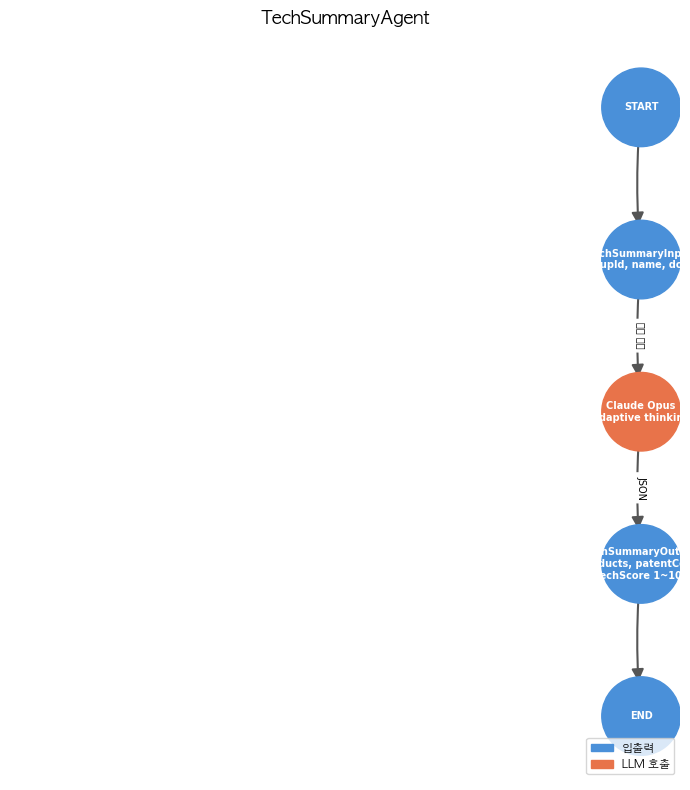

In [4]:
tech_nodes = [
    ("START",               "io"),
    ("TechSummaryInput\n(startupId, name, domain)", "io"),
    ("Claude Opus\n(adaptive thinking)", "llm"),
    ("TechSummaryOutput\n(products, patentCount,\ntechScore 1~10)", "io"),
    ("END",                 "io"),
]

tech_edges = [
    ("START",
     "TechSummaryInput\n(startupId, name, domain)", ""),
    ("TechSummaryInput\n(startupId, name, domain)",
     "Claude Opus\n(adaptive thinking)", "기업 정보"),
    ("Claude Opus\n(adaptive thinking)",
     "TechSummaryOutput\n(products, patentCount,\ntechScore 1~10)", "JSON"),
    ("TechSummaryOutput\n(products, patentCount,\ntechScore 1~10)",
     "END", ""),
]

G_tech = nx.DiGraph()
G_tech.add_nodes_from([n for n, _ in tech_nodes])
G_tech.add_edges_from([(s, t, {'label': l}) for s, t, l in tech_edges])

color_map_t = dict(tech_nodes)
tech_node_colors = [COLORS[color_map_t[n]] for n in G_tech.nodes]

tech_pos = {
    "START":                 (0, 5),
    "TechSummaryInput\n(startupId, name, domain)": (0, 3.5),
    "Claude Opus\n(adaptive thinking)": (0, 2),
    "TechSummaryOutput\n(products, patentCount,\ntechScore 1~10)": (0, 0.5),
    "END":                   (0, -1),
}

fig, ax = plt.subplots(figsize=(7, 8))
draw_graph(G_tech, tech_pos, tech_node_colors,
           "TechSummaryAgent", ax, node_size=3200, font_size=7)

legend_handles = [
    mpatches.Patch(color=COLORS['io'],  label='입출력'),
    mpatches.Patch(color=COLORS['llm'], label='LLM 호출'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 4. 전체 시스템 오버뷰

/Users/bae/Workspace/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bae/Workspace/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bae/Workspace/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bae/Workspace/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/bae/Workspace/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) mis

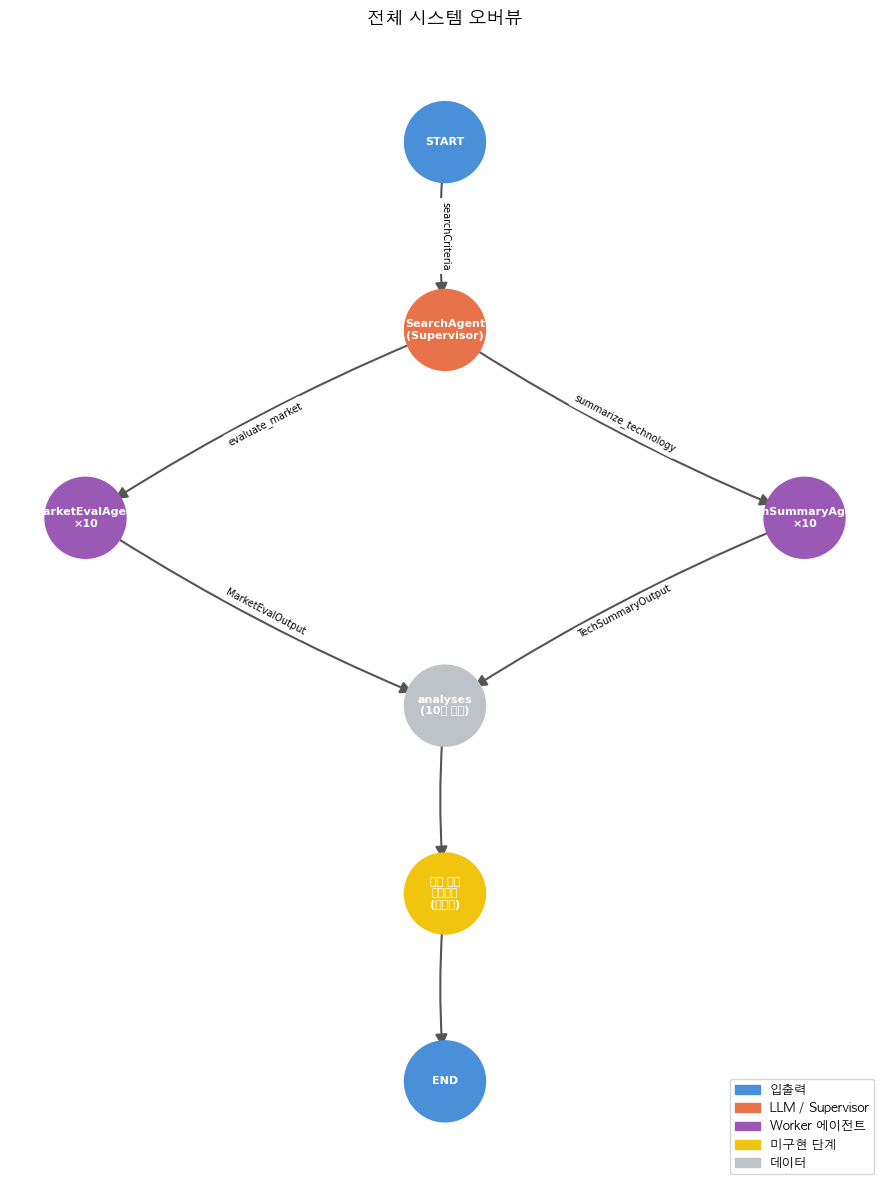

In [5]:
overview_nodes = [
    ("START",               "io"),
    ("SearchAgent\n(Supervisor)", "llm"),
    ("MarketEvalAgent\n×10", "tool"),
    ("TechSummaryAgent\n×10", "tool"),
    ("analyses\n(10개 기업)",  "default"),
    ("다음 단계\n에이전트\n(미구현)", "logic"),
    ("END",                 "io"),
]

overview_edges = [
    ("START",               "SearchAgent\n(Supervisor)",  "searchCriteria"),
    ("SearchAgent\n(Supervisor)", "MarketEvalAgent\n×10",   "evaluate_market"),
    ("SearchAgent\n(Supervisor)", "TechSummaryAgent\n×10",  "summarize_technology"),
    ("MarketEvalAgent\n×10",  "analyses\n(10개 기업)",    "MarketEvalOutput"),
    ("TechSummaryAgent\n×10", "analyses\n(10개 기업)",   "TechSummaryOutput"),
    ("analyses\n(10개 기업)",  "다음 단계\n에이전트\n(미구현)", ""),
    ("다음 단계\n에이전트\n(미구현)", "END", ""),
]

G_overview = nx.DiGraph()
G_overview.add_nodes_from([n for n, _ in overview_nodes])
G_overview.add_edges_from([(s, t, {'label': l}) for s, t, l in overview_edges])

color_map_o = dict(overview_nodes)
overview_node_colors = [COLORS[color_map_o[n]] for n in G_overview.nodes]

overview_pos = {
    "START":                  (0,  8),
    "SearchAgent\n(Supervisor)": (0,  6),
    "MarketEvalAgent\n×10":   (-2.5, 4),
    "TechSummaryAgent\n×10":  ( 2.5, 4),
    "analyses\n(10개 기업)":   (0,  2),
    "다음 단계\n에이전트\n(미구현)": (0,  0),
    "END":                    (0, -2),
}

fig, ax = plt.subplots(figsize=(9, 12))
draw_graph(G_overview, overview_pos, overview_node_colors,
           "전체 시스템 오버뷰", ax, node_size=3400, font_size=8)

legend_handles = [
    mpatches.Patch(color=COLORS['io'],     label='입출력'),
    mpatches.Patch(color=COLORS['llm'],    label='LLM / Supervisor'),
    mpatches.Patch(color=COLORS['tool'],   label='Worker 에이전트'),
    mpatches.Patch(color=COLORS['logic'],  label='미구현 단계'),
    mpatches.Patch(color=COLORS['default'],label='데이터'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()